<a href="https://colab.research.google.com/github/eraj4real/Capstone_Project/blob/master/Distance_GeoMagnetic_Phone1nPhone2_Watch_CNNmodel_Kopya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import the needed libraries

In [ ]:
import pandas as pd
import numpy as np

import pip
pip.main(["install", "openpyxl"])

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Requirement already satisfied: openpyxl in /usr/local/lib/python3.12/dist-packages (3.1.5)

Requirement already satisfied: et-xmlfile in /usr/local/lib/python3.12/dist-packages (from openpyxl) (2.0.0)

DEBUG:2026-01-31 15:29:14,492:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.



### There are three files we will import.  

#### File 1. PointsMapping.xls which simply allocates 325 unique IDs to x and y cordinates collected from a 0.6 x 0.6 meters grid tiles in a pysical building in Italy.

#### File 2. measure1_timestamp_id.csv which simply has readings of the arrival and departure time from each location ID. This has 324 values since there has to be a point of commencement of the journey.

#### File 3. measure1_smartphone_sens.csv. This has 18,354 timestamp readings from sensors on smart phone:
    # Geomagmentic (x, y, z readings) - which we will use
    # Inclinometer readinds (Roll, Pitch, and Yaw) - which we will combine with the magnetometer readings to form a vector
    # Accelerometer readings - which we will not use since I already have a grid map that can represents X, Y translation
    # Gyroscope readings  which we also will not use as they are negligeble. They hardly changed.

#### Import File 1: The map of the capture area

In [ ]:
df_pMap = pd.read_excel("PointsMapping.xlsx", header=0)

# Visualize the data collection area
# Visualize the ground, not actually the path
df_pMap.plot(kind="scatter", x="X", y="Y", alpha=0.2)

df_pMap.head()

FileNotFoundError: [Errno 2] No such file or directory: 'PointsMapping.xlsx'

#### Import File 2. The sensor data collected

In [ ]:
df_TimeFramePhone1 = pd.read_csv("measure1_smartphone_sens.csv")
df_TimeFramePhone1.head()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ
0,1422629483421,-3.577,2.104,9.078,-5.4,-17.9,-28.2,126.404,-12.169,-21.001,0,0,0
1,1422629483520,-3.424,2.927,9.374,-4.3,-21.9,-26.9,134.694,-11.322,-25.898,0,0,0
2,1422629483620,-2.505,2.908,8.867,-0.7,-24.4,-26.5,150.906,-17.523,-15.017,0,0,0
3,1422629483723,-5.473,1.472,9.394,0.3,-25.7,-26.9,138.022,-21.068,-23.941,0,0,0
4,1422629483822,-3.414,2.018,8.187,3.7,-29.6,-23.9,163.519,-12.814,-22.046,0,0,0


In [ ]:
# Information about the dataframe
df_TimeFramePhone1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             18354 non-null  int64  
 1    AccelerationX        18354 non-null  float64
 2    AccelerationY        18354 non-null  float64
 3    AccelerationZ        18354 non-null  float64
 4    MagneticFieldX       18354 non-null  float64
 5    MagneticFieldY       18354 non-null  float64
 6    MagneticFieldZ       18354 non-null  float64
 7    Z-AxisAgle(Azimuth)  18354 non-null  float64
 8    X-AxisAngle(Pitch)   18354 non-null  float64
 9    Y-AxisAngle(Roll)    18354 non-null  float64
 10   GyroX                18354 non-null  int64  
 11   GyroY                18354 non-null  int64  
 12   GyroZ                18354 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.8 MB


#### Import File 3: The arrival and departure time from each location ID

In [ ]:
df_Time_Arrive_Depart_IDPhone1 = pd.read_csv("measure1_timestamp_id.csv",
                                                header=None,
                                                names=["arrival", "departure", "id"]) # use first roll

df_Time_Arrive_Depart_IDPhone1.info()

df_Time_Arrive_Depart_IDPhone1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   arrival    324 non-null    int64
 1   departure  324 non-null    int64
 2   id         324 non-null    int64
dtypes: int64(3)
memory usage: 7.7 KB


,arrival,departure,id
0,1422629490743,1422629492743,34
1,1422629495152,1422629499732,94
2,1422629501522,1422629505849,95
3,1422629507213,1422629511556,35
4,1422629513047,1422629517152,36
...,...,...,...
319,1423127609456,1423127613202,12
320,1423127615028,1423127619099,15
321,1423127620647,1423127624424,19
322,1423127626304,1423127630201,20


####  Extract only the time stamp from File 2. The timestamp from file 2 maps to the arrival and departure time corresoonding to the location ID in file 3.
    # This will help to assign an Location ID to each sensor capture in a single file that will later be created.
    
    # The location ID then corresponds to the specific sensor (geomagnetic, inclinometer, accelerometer,..) data that was captured within arrival and departure time.

In [ ]:
# Just the timestamp aspect from File 2
df_OnlyTimePhone1 = df_TimeFramePhone1["timestamp"]
df_OnlyTimePhone1

0        1422629483421
1        1422629483520
2        1422629483620
3        1422629483723
4        1422629483822
             ...      
18349    1423127642985
18350    1423127643083
18351    1423127643184
18352    1423127643283
18353    1423127643384
Name: timestamp, Length: 18354, dtype: int64

#### This process will take about 6 minutes to run on a 4gb RAM, about 3 minutes on an 8g high prformance RAM, and about 2 minutes on Google Collab. Please be patient

In [ ]:
# Description of the Dataframe having the arrival Time, departure Time and corresponding Location ID
df_Time_Arrive_Depart_IDPhone1.shape

(324, 3)

In [ ]:
print("The number of location arrival and departure times to compare sensor capture time with", df_Time_Arrive_Depart_IDPhone1.shape[0])
print("The total length of timestamps of the  Sensor captures:", len(df_OnlyTimePhone1))

The number of location arrival and departure times to compare sensor capture time with 324
The total length of timestamps of the  Sensor captures: 18354


          # The process that will take time

In [ ]:
%%time

# What this does is to take each of the 18354 timestamps and check which arrival and departure time it corresponds to
# Then store the corresponding Location ID and the correponding Timestamp
row_lenth = df_Time_Arrive_Depart_IDPhone1.shape[0] # This is 324, as there are 324 Arrival times and Departure times from 324 unique location IDs

listIDPhone1  = [] # To hold the location IDs
listTimePhone1 = [] # To hold the correponding Timestamp

for timeStamp in df_OnlyTimePhone1:          # Each time stamp in the 18354 sensor captures
    for i in range(row_lenth):         # Each of the 324 rows corresponding to the unique Place IDs
                                       # The comparison below  takes each of the 18324 time stamps and check the arrival time it is greater than, and the departure time it is less than or equal
        if (timeStamp > df_Time_Arrive_Depart_IDPhone1["arrival"][i]) and (timeStamp <= df_Time_Arrive_Depart_IDPhone1["departure"][i]):
            listIDPhone1.append(df_Time_Arrive_Depart_IDPhone1["id"][i]) # Apend the location ID that meets this requirement
            listTimePhone1.append(timeStamp) # Apend the timestamp that meets this requirement. I.e. The timestamp the exact capture took place

CPU times: user 47.7 s, sys: 157 ms, total: 47.9 s
Wall time: 53.6 s


In [ ]:
len(listIDPhone1)

11498

In [ ]:
len(listTimePhone1)

11498

In [ ]:
#This worrked perfectly well and matched the ground truth as shown in 2 different research papers. To explain the numbers,
# At each point in time, for example between moving from location id 34 to 94, 19 readings were taken while moving. These readings were taken in milliseconds.

listIDPhone1[:10]

[34, 34, 34, 34, 34, 34, 34, 34, 34, 34]

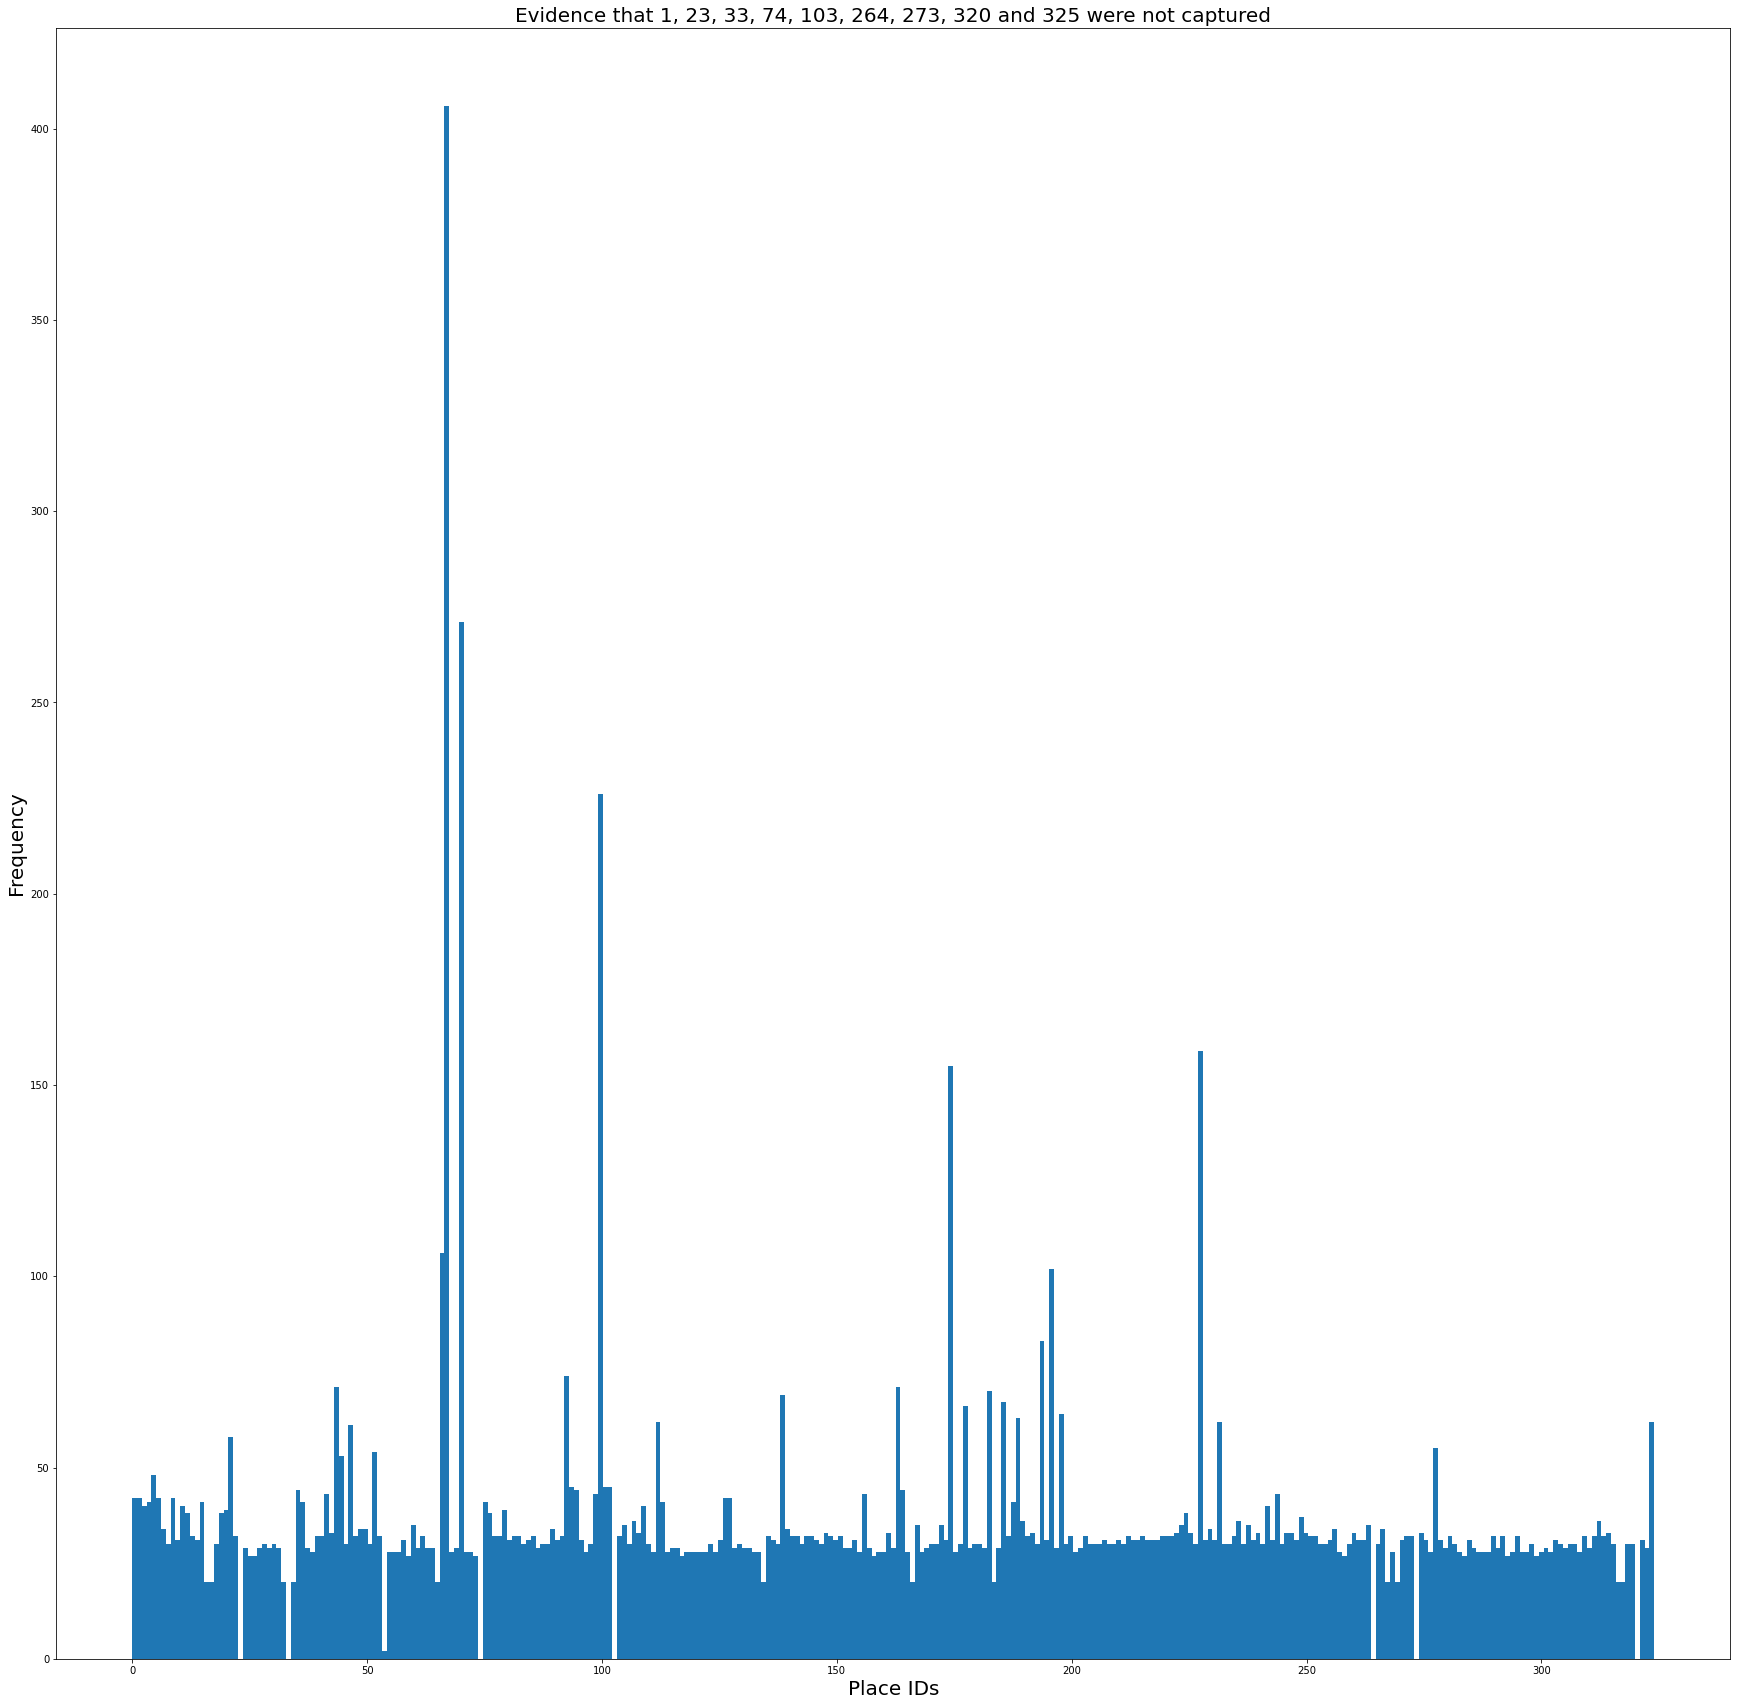

In [ ]:
plt.figure(figsize=(30,30))
plt.hist(listIDPhone1,  bins=(len(set(listIDPhone1))))  # density=False would make counts
plt.ylabel('Frequency', fontsize=20)
plt.xlabel('Place IDs' , fontsize=20);
plt.title('Evidence that 1, 23, 33, 74, 103, 264, 273, 320 and 325 were not captured', fontsize=20);

plt.show()

In [ ]:
# Path
pathPhone1 = []

for ID in listIDPhone1:
    if ID not in pathPhone1:
        pathPhone1.append(ID)


# path # The actual path the recording took place. May be useful for future research

In [ ]:
len(pathPhone1)

317

In [ ]:
df_pMap

,ID,X,Y,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,0.6,0.6,NaN,NaN,NaN,NaN
1,2,1.2,0.6,NaN,NaN,Min ID,1.0
2,3,1.8,0.6,NaN,NaN,NaN,NaN
3,4,0.6,1.2,NaN,NaN,NaN,NaN
4,5,1.8,1.2,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
320,321,30.6,34.2,NaN,NaN,NaN,NaN
321,322,31.2,34.2,NaN,NaN,NaN,NaN
322,323,31.8,34.2,NaN,NaN,NaN,NaN
323,324,32.4,34.2,NaN,NaN,NaN,NaN


In [ ]:
path_x_cordsPhone1 = []
path_y_cordsPhone1 = []
# Phone1PathFrequency = [] # Was used to crosscheck what was happening

for id in pathPhone1:
    if id == 0: # Dataset author skipped  in their mapping that cordinate 0,0 was transvered
            path_x_cordsPhone1.append(0.0)
            path_y_cordsPhone1.append(0.0)
#             Phone1PathFrequency.append(id)
    for i in range(df_pMap.shape[0]):
        if df_pMap["ID"][i] == id:
            path_x_cordsPhone1.append(df_pMap["X"][i])
            path_y_cordsPhone1.append(df_pMap["Y"][i])
#             Phone1PathFrequency.append(id)




In [ ]:
len(path_x_cordsPhone1)

317

In [ ]:
len(path_y_cordsPhone1)

317

In [ ]:
# Check whether there are some place IDs with very few occurence
import collections

listIDSorted = sorted(listIDPhone1)
counter = collections.Counter(listIDSorted)
counter

# Scroll to the index 54. You will observe it is too poor. This will make a stratified train test split improper

Counter({0: 42,
         2: 42,
         3: 40,
         4: 41,
         5: 48,
         6: 42,
         7: 34,
         8: 30,
         9: 42,
         10: 31,
         11: 40,
         12: 38,
         13: 32,
         14: 31,
         15: 41,
         16: 20,
         17: 20,
         18: 30,
         19: 38,
         20: 39,
         21: 58,
         22: 32,
         24: 29,
         25: 27,
         26: 27,
         27: 29,
         28: 30,
         29: 29,
         30: 30,
         31: 29,
         32: 20,
         34: 20,
         35: 44,
         36: 41,
         37: 29,
         38: 28,
         39: 32,
         40: 32,
         41: 43,
         42: 33,
         43: 71,
         44: 53,
         45: 30,
         46: 30,
         47: 31,
         48: 32,
         49: 34,
         50: 34,
         51: 30,
         52: 54,
         53: 32,
         54: 2,
         55: 28,
         56: 28,
         57: 28,
         58: 31,
         59: 27,
         60: 35,
         61: 29,
       

In [ ]:
df_pMap.shape[0]

325

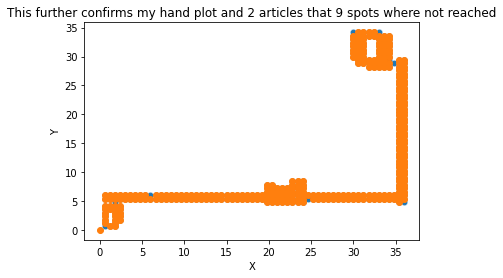

In [ ]:

df_pMap.plot(kind="scatter", x="X", y="Y",)

plt.scatter(df_pMap.X, df_pMap.Y, alpha=0.2)
plt.scatter(path_x_cordsPhone1, path_y_cordsPhone1, alpha=1.0)

plt.title("This further confirms my hand plot and 2 articles that 9 spots where not reached") # Further improvedment should plot the exact path
plt.show()

# This will also enable me know where I did not reach in my field capture


![missing_points.png](attachment:missing_points.png)

#### Filter out only the relevant readings. The Readings filtered out were those that started reading before an actual path was logged, and those that occured after when there was change of paths. We will then be left with 11498 useful sensor readings as they correspond to actual location IDs

In [ ]:
# df_TimeFramePhone1 is the complete 18354 magnetometer, inclinometer readings...

df_TimeFramePhone1 = df_TimeFramePhone1[df_TimeFramePhone1['timestamp'].isin(listTimePhone1)] # The listTime corresponds with listID, recall they were created in the same condition statement
df_TimeFramePhone1.shape
 # Now filtered

(11498, 13)

In [ ]:
df_TimeFramePhone1.head()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ
74,1422629490821,-0.656,2.410,9.078,-16.0,14.2,-28.2,40.720,-14.825,-3.992,0,0,0
75,1422629490922,0.148,2.602,9.480,-16.0,13.6,-28.2,42.962,-12.337,-4.027,0,0,0
76,1422629491021,0.474,2.468,9.202,-16.4,13.0,-28.2,37.137,-14.982,2.842,0,0,0
77,1422629491121,0.052,3.282,9.135,-16.4,11.8,-28.2,38.238,-19.758,0.300,0,0,0
78,1422629491221,-0.474,2.966,8.800,-16.4,11.8,-28.2,39.383,-16.733,0.947,0,0,0


In [ ]:
df_TimeFramePhone1.tail()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ
18254,1423127633485,-1.758,6.241,7.756,-17.3,-27.6,-18.5,115.056,-40.161,-9.257,0,0,0
18255,1423127633585,-1.480,6.461,7.641,-16.8,-27.6,-18.5,117.724,-38.127,-10.013,0,0,0
18256,1423127633685,-1.375,6.767,7.114,-16.8,-28.2,-17.8,118.344,-39.696,-8.408,0,0,0
18257,1423127633784,-1.758,6.183,8.311,-16.8,-28.6,-17.8,118.119,-39.771,-10.886,0,0,0
18258,1423127633886,-1.346,6.729,7.622,-16.8,-29.2,-16.8,124.909,-36.049,-9.628,0,0,0


In [ ]:
# Reset the index
df_TimeFramePhone1 =  df_TimeFramePhone1.reset_index(drop=True)

In [ ]:
df_TimeFramePhone1.head()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ
0,1422629490821,-0.656,2.410,9.078,-16.0,14.2,-28.2,40.720,-14.825,-3.992,0,0,0
1,1422629490922,0.148,2.602,9.480,-16.0,13.6,-28.2,42.962,-12.337,-4.027,0,0,0
2,1422629491021,0.474,2.468,9.202,-16.4,13.0,-28.2,37.137,-14.982,2.842,0,0,0
3,1422629491121,0.052,3.282,9.135,-16.4,11.8,-28.2,38.238,-19.758,0.300,0,0,0
4,1422629491221,-0.474,2.966,8.800,-16.4,11.8,-28.2,39.383,-16.733,0.947,0,0,0


In [ ]:
df_TimeFramePhone1.tail()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ
11493,1423127633485,-1.758,6.241,7.756,-17.3,-27.6,-18.5,115.056,-40.161,-9.257,0,0,0
11494,1423127633585,-1.480,6.461,7.641,-16.8,-27.6,-18.5,117.724,-38.127,-10.013,0,0,0
11495,1423127633685,-1.375,6.767,7.114,-16.8,-28.2,-17.8,118.344,-39.696,-8.408,0,0,0
11496,1423127633784,-1.758,6.183,8.311,-16.8,-28.6,-17.8,118.119,-39.771,-10.886,0,0,0
11497,1423127633886,-1.346,6.729,7.622,-16.8,-29.2,-16.8,124.909,-36.049,-9.628,0,0,0


In [ ]:
df_TimeFramePhone1.shape
# Before adding

(11498, 13)

    # Now add the listIDPhone1 as a column

In [ ]:
# Add the ID to the
df_TimeFramePhone1.loc[:,'id'] = listIDPhone1

In [ ]:
df_TimeFramePhone1.shape
# After adding id

(11498, 14)

In [ ]:
df_TimeFramePhone1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11498 entries, 0 to 11497
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             11498 non-null  int64  
 1    AccelerationX        11498 non-null  float64
 2    AccelerationY        11498 non-null  float64
 3    AccelerationZ        11498 non-null  float64
 4    MagneticFieldX       11498 non-null  float64
 5    MagneticFieldY       11498 non-null  float64
 6    MagneticFieldZ       11498 non-null  float64
 7    Z-AxisAgle(Azimuth)  11498 non-null  float64
 8    X-AxisAngle(Pitch)   11498 non-null  float64
 9    Y-AxisAngle(Roll)    11498 non-null  float64
 10   GyroX                11498 non-null  int64  
 11   GyroY                11498 non-null  int64  
 12   GyroZ                11498 non-null  int64  
 13  id                    11498 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 1.2 MB


#### Now make a new dataframe out of this initially preprocesssed data

In [ ]:
df_TimeFramePhone1.to_csv('geoMagXandIDPhone1.csv', index=False)

### Now commence brief preprocessing of the new file that was created

In [ ]:
# For my single file relevant geomagnetic data
geodata_pdPhone1 = pd.read_csv("geoMagXandIDPhone1.csv")
geodata_pdPhone1.head()

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,id
0,1422629490821,-0.656,2.410,9.078,-16.0,14.2,-28.2,40.720,-14.825,-3.992,0,0,0,34
1,1422629490922,0.148,2.602,9.480,-16.0,13.6,-28.2,42.962,-12.337,-4.027,0,0,0,34
2,1422629491021,0.474,2.468,9.202,-16.4,13.0,-28.2,37.137,-14.982,2.842,0,0,0,34
3,1422629491121,0.052,3.282,9.135,-16.4,11.8,-28.2,38.238,-19.758,0.300,0,0,0,34
4,1422629491221,-0.474,2.966,8.800,-16.4,11.8,-28.2,39.383,-16.733,0.947,0,0,0,34


In [ ]:
# Somehow, the column names have space in them
geodata_pdPhone1.columns.values

array(['timestamp', ' AccelerationX', ' AccelerationY', ' AccelerationZ',
       ' MagneticFieldX', ' MagneticFieldY', ' MagneticFieldZ',
       ' Z-AxisAgle(Azimuth)', ' X-AxisAngle(Pitch)',
       ' Y-AxisAngle(Roll)', ' GyroX', ' GyroY', ' GyroZ', 'id'],
      dtype=object)

In [ ]:
# This timestamp can actually be used to seperate the paths, as time between paths will be larger than the nirmal time.
# Though I manually traced the path, this can help as input into the building of my data capture app

In [ ]:
# remove space in column names
new_coumn_names = {' AccelerationX':'AccelerationX', ' AccelerationY':"AccelerationY", ' AccelerationZ':"AccelerationZ",
                   ' MagneticFieldX':"MagneticFieldX", ' MagneticFieldY':"MagneticFieldY", ' MagneticFieldZ':"MagneticFieldZ",
                   ' Z-AxisAgle(Azimuth)':"Azimuth_Z", ' X-AxisAngle(Pitch)':"Pitch_X", ' Y-AxisAngle(Roll)':"Roll_Y", ' GyroX':"GyroX", ' GyroY':"GyroY", ' GyroZ':"GyroZ"}
geodata_pdPhone1.rename(columns = new_coumn_names, inplace = True)
geodata_pdPhone1.columns.values

array(['timestamp', 'AccelerationX', 'AccelerationY', 'AccelerationZ',
       'MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ', 'Azimuth_Z',
       'Pitch_X', 'Roll_Y', 'GyroX', 'GyroY', 'GyroZ', 'id'], dtype=object)

#### Select the features we will be using, which is only:
    [MagneticFieldX, 	MagneticFieldY, 	MagneticFieldZ, 	Roll_Y, 	Pitch_X, 	Azimuth_Z]

In [ ]:
features = ["MagneticFieldX", "MagneticFieldY", "MagneticFieldZ", "Roll_Y", "Pitch_X", "Azimuth_Z"]
Phone1GeodataX =  geodata_pdPhone1[features]
Phone1GeodataY = geodata_pdPhone1["id"]

Phone1GeodataX

,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Roll_Y,Pitch_X,Azimuth_Z
0,-16.0,14.2,-28.2,-3.992,-14.825,40.720
1,-16.0,13.6,-28.2,-4.027,-12.337,42.962
2,-16.4,13.0,-28.2,2.842,-14.982,37.137
3,-16.4,11.8,-28.2,0.300,-19.758,38.238
4,-16.4,11.8,-28.2,0.947,-16.733,39.383
...,...,...,...,...,...,...
11493,-17.3,-27.6,-18.5,-9.257,-40.161,115.056
11494,-16.8,-27.6,-18.5,-10.013,-38.127,117.724
11495,-16.8,-28.2,-17.8,-8.408,-39.696,118.344
11496,-16.8,-28.6,-17.8,-10.886,-39.771,118.119


In [ ]:
# To pandas DF to numpy array to ease manipulation
X = np.array(Phone1GeodataX)
X

array([[-16.   ,  14.2  , -28.2  ,  -3.992, -14.825,  40.72 ],
       [-16.   ,  13.6  , -28.2  ,  -4.027, -12.337,  42.962],
       [-16.4  ,  13.   , -28.2  ,   2.842, -14.982,  37.137],
       ...,
       [-16.8  , -28.2  , -17.8  ,  -8.408, -39.696, 118.344],
       [-16.8  , -28.6  , -17.8  , -10.886, -39.771, 118.119],
       [-16.8  , -29.2  , -16.8  ,  -9.628, -36.049, 124.909]])

In [ ]:
# From Pandas series To numpy array to ease manipulation
tmpY = np.array(Phone1GeodataY)
tmpY

array([34, 34, 34, ..., 16, 16, 16])

#### Relabel the targets from 0 to 316 to enable one hot encoding the targets to utilize categorical entropy loss function

In [ ]:
seriesID = pd.Series(tmpY)
orderedSeries = seriesID.astype("category").cat.codes
Y = orderedSeries
Y

0        31
1        31
2        31
3        31
4        31
         ..
11493    15
11494    15
11495    15
11496    15
11497    15
Length: 11498, dtype: int16

#### Split the data before normalizing.

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15,
                                                    shuffle=True,
                                                    stratify=Y,  # To ensure all sets in training and represented in testing
                                                    random_state=42)

# Redo this, but observe, 1, 74 and some are not there. Also 0 should be rmoved. The Author rename them though

In [ ]:
len(set(y_train))

317

In [ ]:
len(set(y_test))

316

In [ ]:
if (len(set(y_train)) != len(set(y_test))):
    print("Training will generate an error because the test set does not have all samples of the train set. This is due to imbalanced classification. See  error in image below")

Training will generate an error because the test set does not have all samples of the train set. This is due to imbalanced classification. See  error in image below


### Image showing that training with only one Phone capture will create a problem when training a CNN deep learning model
![failPoint.PNG](attachment:failPoint.PNG)

In [ ]:
#### We need to augment with more data. Since there is a second phone record, let us opt for it

## The data is imbalanced and cannot be split evenly. Create more data using captures from the second mobile phone. This also is a warning that in actual test, multiple captures should be done

In [ ]:
# A simple repetion of steps done before, but with files representing the second phone
df_TimeFramePhone2 = pd.read_csv("measure2_phone_sens.csv")

# Just the timestamp aspect from File 2
df_OnlyTimePhone2 = df_TimeFramePhone2["timestamp"]

df_Time_Arrive_Depart_IDPhone2 = pd.read_csv("measure2_timestamp_id.csv",
                                                header=None,
                                                names=["arrival", "departure", "id"]) # use first roll

In [ ]:
%%time

# What this does is to take each of the 18354 timestamps and check which arrival and departure time it corresponds to
# Then store the corresponding Location ID and the correponding Timestamp
row_lenth2 = df_Time_Arrive_Depart_IDPhone2.shape[0] # This is 324, as there are 324 Arrival times and Departure times from 324 unique location IDs

listIDPhone2  = [] # To hold the location IDs
listTimePhone2 = [] # To hold the correponding Timestamp

for timeStamp in df_OnlyTimePhone2:          # Each time stamp in the 18354 sensor captures
    for i in range(row_lenth2):         # Each of the 324 rows corresponding to the unique Place IDs
                                       # The comparison below  takes each of the 18324 time stamps and check the arrival time it is greater than, and the departure time it is less than or equal
        if (timeStamp > df_Time_Arrive_Depart_IDPhone2["arrival"][i]) and (timeStamp <= df_Time_Arrive_Depart_IDPhone2["departure"][i]):
            listIDPhone2.append(df_Time_Arrive_Depart_IDPhone2["id"][i]) # Apend the location ID that meets this requirement
            listTimePhone2.append(timeStamp) # Apend the timestamp that meets this requirement. I.e. The timestamp the exact capture took place

CPU times: user 50.7 s, sys: 165 ms, total: 50.9 s
Wall time: 59.3 s


In [ ]:
len(listIDPhone2)

10529

In [ ]:
len(listTimePhone2)

10529

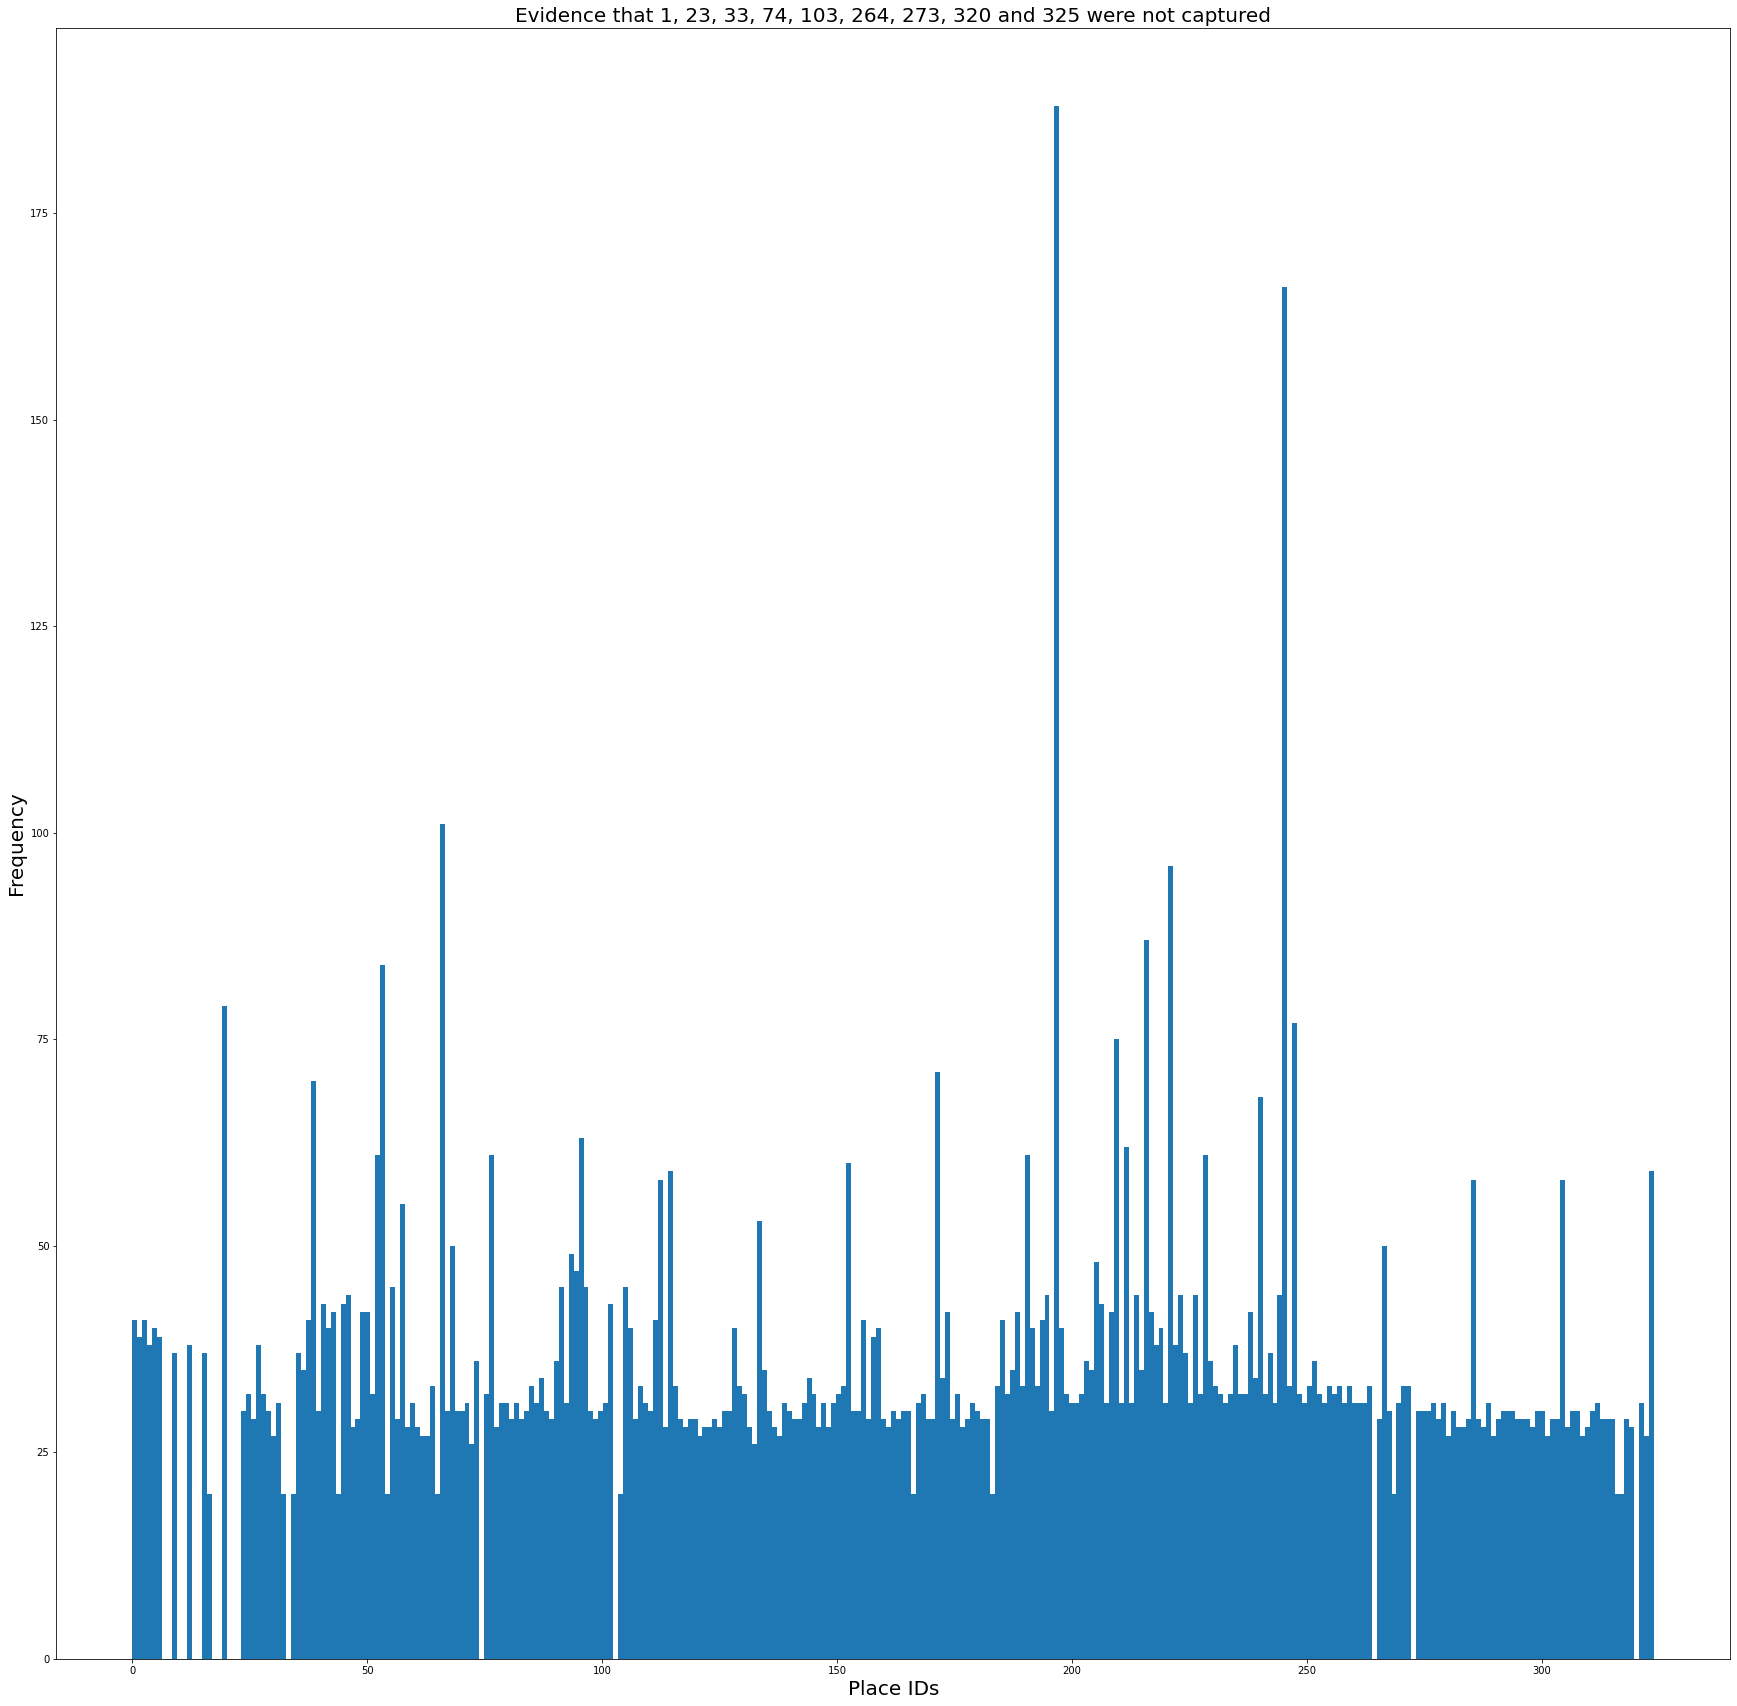

In [ ]:
plt.figure(figsize=(30,30))
plt.hist(listIDPhone2,  bins=(len(set(listIDPhone2))))  # density=False would make counts
plt.ylabel('Frequency', fontsize=20)
plt.xlabel('Place IDs' , fontsize=20);
plt.title('Evidence that 1, 23, 33, 74, 103, 264, 273, 320 and 325 were not captured', fontsize=20);

plt.show()

In [ ]:
# Data above is worse, but it will augment the existing data in various Place IDs

Number of IDs where sensor data was captured in the second file:  307
number of uncaptured sensor data on path IDs in file_2:  18
307
307


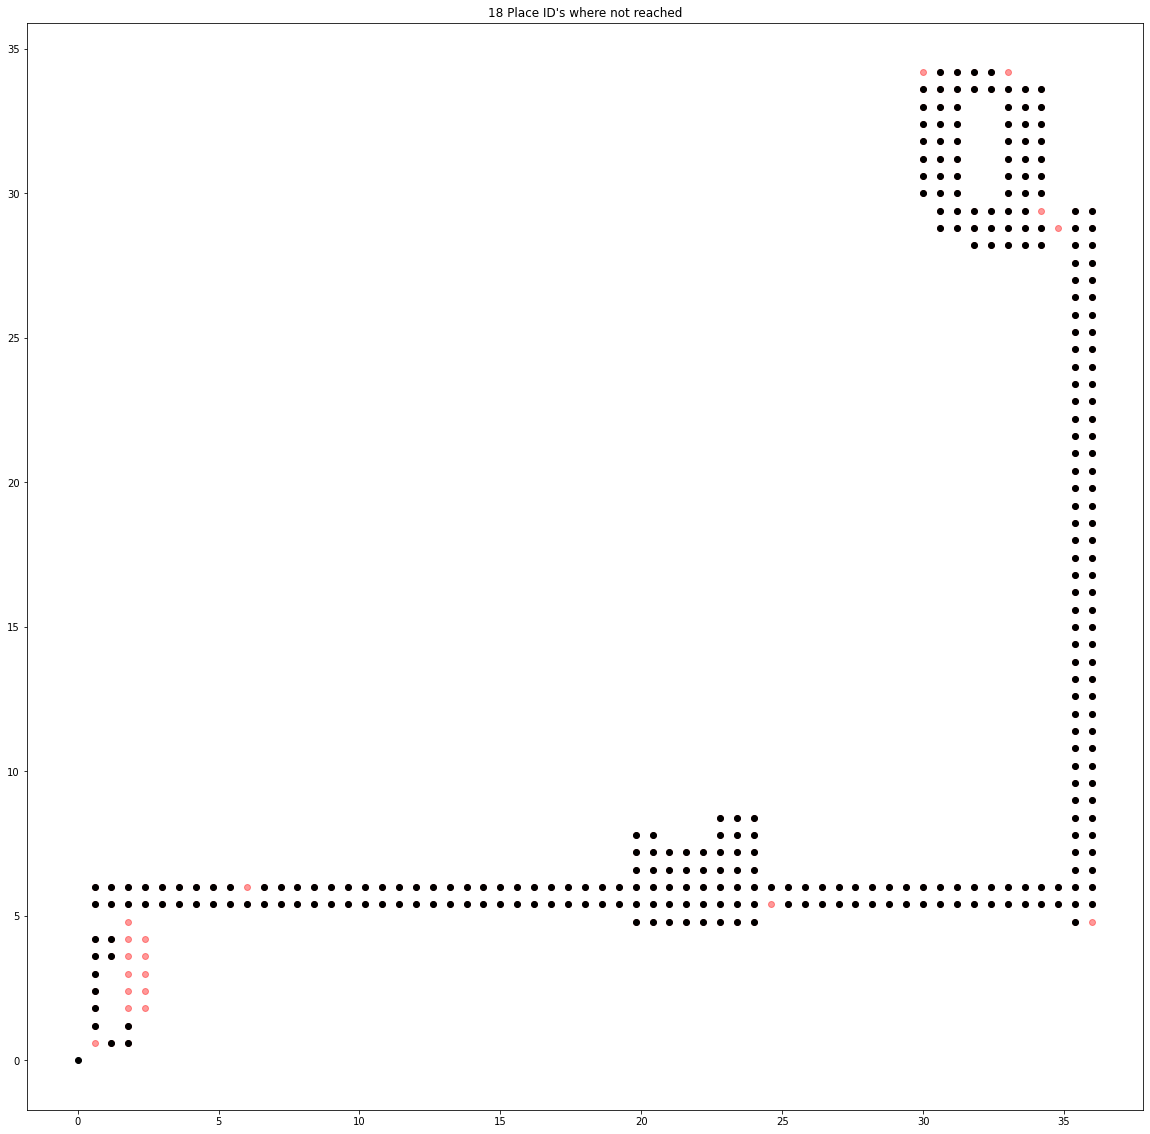

In [ ]:
# Path
pathPhone2 = []

for ID in listIDPhone2:
    if ID not in pathPhone2:
        pathPhone2.append(ID)


# path # The actual path the recording took place. May be useful for future research

print("Number of IDs where sensor data was captured in the second file: ", len(pathPhone2))

print("number of uncaptured sensor data on path IDs in file_2: ", df_pMap.shape[0] - len(pathPhone2))



path_x_cordsPhone2 = []
path_y_cordsPhone2 = []
# Phone2PathFrequency = [] # Was used to crosscheck what was happening

for id in pathPhone2:
    if id == 0: # Dataset author skipped  in their mapping that cordinate 0,0 was transvered
            path_x_cordsPhone2.append(0.0)
            path_y_cordsPhone2.append(0.0)
#             Phone2PathFrequency.append(id)
    for i in range(df_pMap.shape[0]):
        if df_pMap["ID"][i] == id:
            path_x_cordsPhone2.append(df_pMap["X"][i])
            path_y_cordsPhone2.append(df_pMap["Y"][i])
#             Phone2PathFrequency.append(id)


print(len(path_x_cordsPhone2))
print(len(path_y_cordsPhone2))


# Check whether there are some place IDs with very few occurence
import collections

listIDSorted2 = sorted(listIDPhone2)
counter = collections.Counter(listIDSorted2)

# Scroll to see whether index 54 was captured. It caused the problem in the former data. This will make a stratified train test split proper


# df_pMap.plot(kind="scatter", x="X", y="Y", figsize=(30, 30))
plt.figure(figsize=(20, 20))
plt.scatter(df_pMap.X, df_pMap.Y, alpha=0.4, color='red')
plt.scatter(path_x_cordsPhone2, path_y_cordsPhone2, alpha=1.0, color='black')

plt.title("18 Place ID's where not reached") # Further improvedment should plot the exact path
plt.show()

# This will also enable me know where I did not reach in my field capture


#### Confirm the reach of the two Phone captures combined. As observed, the 9 spots, are still not reached. We can now remove them.

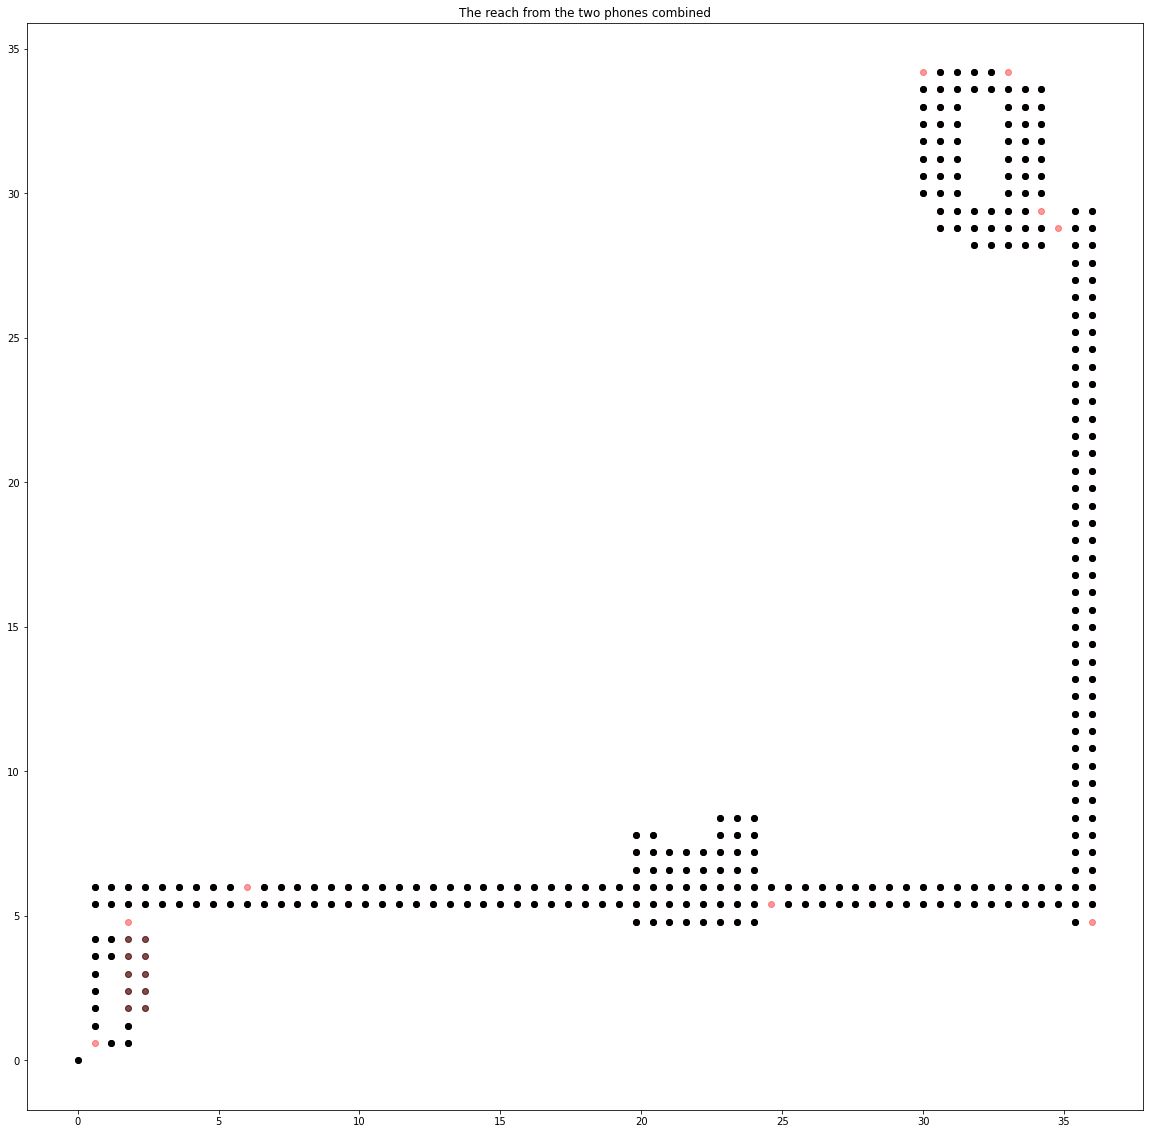

In [ ]:
plt.figure(figsize=(20, 20))
plt.scatter(df_pMap.X, df_pMap.Y, alpha=0.4, color='red')
plt.scatter(path_x_cordsPhone2, path_y_cordsPhone2, alpha=1.0, color='black')
plt.scatter(path_x_cordsPhone1, path_y_cordsPhone1, alpha=0.5, color='black')

plt.title("The reach from the two phones combined") # Further improvedment should plot the exact path
plt.show()


#### Filter out only the relevant readings in Phone capture 2. T We will then be left with 1529 useful sensor readings as they correspond to actual location IDs

In [ ]:
# df_timeFrame is the complete 18354 magnetometer, inclinometer readings...

df_TimeFramePhone2 = df_TimeFramePhone2[df_TimeFramePhone2['timestamp'].isin(listTimePhone2)] # The listTime corresponds with listID, recall they were created in the same condition statement
print("The shape of :", df_TimeFramePhone2.shape)
print()
 # Now filtered

# Reset the index
df_TimeFramePhone2 =  df_TimeFramePhone2.reset_index(drop=True)


# Now add the corresponding list ID as a column
# Add the ID to the
df_TimeFramePhone2.loc[:,'id'] = listIDPhone2
print("The New shape of :", df_TimeFramePhone2.shape)

# MAKE A NEW DATAFRAME USING PHONE 2 SENSOR DATA
df_TimeFramePhone2.to_csv('geoMagXandIDPhone2.csv', index=False)

The shape of : (10529, 13)

The New shape of : (10529, 14)


In [ ]:
df_TimeFramePhone2.to_csv('geoMagXandIDPhone2.csv', index=False)

# For my single file relevant geomagnetic data from Phone2
geodata_pdPhone2 = pd.read_csv("geoMagXandIDPhone2.csv")

# Rename the columns
# Somehow, the column names have space in them
print("Initial Label names: ", geodata_pdPhone2.columns.values)
print()

# remove space in column names
new_coumn_names = {' AccelerationX':'AccelerationX', ' AccelerationY':"AccelerationY", ' AccelerationZ':"AccelerationZ",
                   ' MagneticFieldX':"MagneticFieldX", ' MagneticFieldY':"MagneticFieldY", ' MagneticFieldZ':"MagneticFieldZ",
                   ' Z-AxisAgle(Azimuth)':"Azimuth_Z", ' X-AxisAngle(Pitch)':"Pitch_X", ' Y-AxisAngle(Roll)':"Roll_Y", ' GyroX':"GyroX", ' GyroY':"GyroY", ' GyroZ':"GyroZ"}
geodata_pdPhone2.rename(columns = new_coumn_names, inplace = True)
print("Improved label names: ", geodata_pdPhone2.columns.values)

# Select the features we will be using, which is only:
# [MagneticFieldX,     MagneticFieldY,     MagneticFieldZ,     Roll_Y,     Pitch_X,     Azimuth_Z]

Initial Label names:  ['timestamp' ' AccelerationX' ' AccelerationY' ' AccelerationZ'
 ' MagneticFieldX' ' MagneticFieldY' ' MagneticFieldZ'
 ' Z-AxisAgle(Azimuth)' ' X-AxisAngle(Pitch)' ' Y-AxisAngle(Roll)'
 ' GyroX' ' GyroY' ' GyroZ' 'id']

Improved label names:  ['timestamp' 'AccelerationX' 'AccelerationY' 'AccelerationZ'
 'MagneticFieldX' 'MagneticFieldY' 'MagneticFieldZ' 'Azimuth_Z' 'Pitch_X'
 'Roll_Y' 'GyroX' 'GyroY' 'GyroZ' 'id']


In [ ]:
geodata_pdPhone1.shape

(11498, 14)

In [ ]:
geodata_pdPhone2.shape

(10529, 14)

#### Now combine the two datasets (Phone 1 and Phone2)

In [ ]:
df_geodata_BothPhones = pd.concat([geodata_pdPhone1, geodata_pdPhone2])

# Reset the index
df_geodata_BothPhones =  df_geodata_BothPhones.reset_index(drop=True)
display(df_geodata_BothPhones)

,timestamp,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Azimuth_Z,Pitch_X,Roll_Y,GyroX,GyroY,GyroZ,id
0,1422629490821,-0.656,2.410,9.078,-16.0,14.2,-28.2,40.720,-14.825,-3.992,0,0,0,34
1,1422629490922,0.148,2.602,9.480,-16.0,13.6,-28.2,42.962,-12.337,-4.027,0,0,0,34
2,1422629491021,0.474,2.468,9.202,-16.4,13.0,-28.2,37.137,-14.982,2.842,0,0,0,34
3,1422629491121,0.052,3.282,9.135,-16.4,11.8,-28.2,38.238,-19.758,0.300,0,0,0,34
4,1422629491221,-0.474,2.966,8.800,-16.4,11.8,-28.2,39.383,-16.733,0.947,0,0,0,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22022,1423127749888,-0.369,5.810,7.813,-14.7,-29.6,-11.9,137.666,-36.596,-2.167,0,0,0,16
22023,1423127749988,-0.158,5.896,7.555,-14.2,-30.0,-11.9,138.724,-37.967,-0.943,0,0,0,16
22024,1423127750086,-0.254,5.810,7.967,-14.2,-30.0,-11.9,139.353,-36.685,-1.650,0,0,0,16
22025,1423127750187,-0.283,5.848,7.727,-14.2,-30.0,-11.9,139.002,-37.101,-1.671,0,0,0,16


In [ ]:
# Check whether there are some place IDs with very few occurence
import collections

ID_Sorted = sorted(df_geodata_BothPhones["id"])
counter = collections.Counter(ID_Sorted)


print("The minimum number of sensor captures for any ID: ", min(counter.values()))
print("The maximum number of sensor captures for any ID: ", max(counter.values()))

# Scroll to

The minimum number of sensor captures for any ID:  20
The maximum number of sensor captures for any ID:  436


#### We can now train our model effectively

In [ ]:
features = ["MagneticFieldX", "MagneticFieldY", "MagneticFieldZ", "Roll_Y", "Pitch_X", "Azimuth_Z"]
geodataX =  df_geodata_BothPhones[features]
geodataY = df_geodata_BothPhones["id"]

display(geodataX)
display(geodataY)

,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Roll_Y,Pitch_X,Azimuth_Z
0,-16.0,14.2,-28.2,-3.992,-14.825,40.720
1,-16.0,13.6,-28.2,-4.027,-12.337,42.962
2,-16.4,13.0,-28.2,2.842,-14.982,37.137
3,-16.4,11.8,-28.2,0.300,-19.758,38.238
4,-16.4,11.8,-28.2,0.947,-16.733,39.383
...,...,...,...,...,...,...
22022,-14.7,-29.6,-11.9,-2.167,-36.596,137.666
22023,-14.2,-30.0,-11.9,-0.943,-37.967,138.724
22024,-14.2,-30.0,-11.9,-1.650,-36.685,139.353
22025,-14.2,-30.0,-11.9,-1.671,-37.101,139.002


0        34
1        34
2        34
3        34
4        34
         ..
22022    16
22023    16
22024    16
22025    16
22026    16
Name: id, Length: 22027, dtype: int64

In [ ]:
# To pandas DF to numpy array to ease manipulation
X = np.array(geodataX)
tmpY = np.array(geodataY)

In [ ]:
print("Number of Unique Labels: ", len(set(tmpY)))

Number of Unique Labels:  317


#### Relabel the targets from 0 to 316 to enable one hot encoding the targets to utilize categorical entropy loss function

In [ ]:
seriesID = pd.Series(tmpY)
orderedSeries = seriesID.astype("category").cat.codes
Y = orderedSeries
Y

0        31
1        31
2        31
3        31
4        31
         ..
22022    15
22023    15
22024    15
22025    15
22026    15
Length: 22027, dtype: int16

#Two phones

#### Split the data before normalizing. The training the model using 3 dense and dropout

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15,
                                                    shuffle=True,
                                                    stratify=Y,  # To ensure all sets in training and represented in testing
                                                    random_state=42)


lengthY_train = len(set(y_train))
lengthY_test = len(set(y_test))

if (lengthY_train != lengthY_test): # Test whether training and testing set are equal
    print("Training will generate an error because the test set does not have all samples of the train set. This is due to imbalanced classification. See  error in image below")
else:
    print("All targets are captured in both the training, testing and validating set. \nThe splitting was properly stratified")

print("The shape of training set", X_train.shape)
print("The shape of testing set", X_test.shape)


# normalize the training and testing data features using min max normalization
X_trainN = (X_train-np.min(X_train))/(np.max(X_train)-np.min(X_train))
X_testN = (X_test-np.min(X_test))/(np.max(X_test)-np.min(X_test))
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)


# Reshape the Training and testing features data to 2x3 vector
X_trainN = X_trainN.reshape(-1, 2, 3)
X_testN = X_testN.reshape(-1, 2, 3)
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)


# Add an extra dimension to both data to meet the CNN model requirement
X_trainN = np.expand_dims(X_trainN, -1)
X_testN = np.expand_dims(X_testN, -1)
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)



# number of classes in train
K = len(set(y_train))
print("number of classes: ", K)


# One hot encode the targets

y_train = to_categorical(y_train, K)
y_test = to_categorical(y_test, K)



# Build the model using the fucntional API
i = Input(shape=X_trainN[0].shape) # same as (2, 3, 1)
x = Conv2D(16, (1,1), strides=1, activation='relu')(i)
x = Conv2D(32, (1,1), strides=1, activation='relu')(x)
x = Flatten()(x) # convert matrix into feature vector
x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile and fit
# Note: make sure you are using the GPU for this:
opt = tf.keras.optimizers.Adam(0.0001)
model.compile(optimizer= opt, # Default learning rate was very poor as accuracy was bellow 1%
              loss='categorical_crossentropy', # sparse_categorical_crossentropy scored below 1%
              metrics=['accuracy'])
r = model.fit(X_trainN, y_train, validation_data=(X_testN, y_test), epochs=400)




All targets are captured in both the training, testing and validating set. 
The splitting was properly stratified
The shape of training set (18722, 6)
The shape of testing set (3305, 6)
The shape of training set (18722, 6)
The shape of testing set (3305, 6)
The shape of training set (18722, 2, 3)
The shape of testing set (3305, 2, 3)
The shape of training set (18722, 2, 3, 1)
The shape of testing set (3305, 2, 3, 1)
number of classes:  317
Epoch 1/400
586/586 [==============================] - 13s 5ms/step - loss: 5.7071 - accuracy: 0.0179 - val_loss: 5.6075 - val_accuracy: 0.0197
Epoch 2/400
586/586 [==============================] - 3s 5ms/step - loss: 5.4283 - accuracy: 0.0187 - val_loss: 5.1251 - val_accuracy: 0.0166
Epoch 3/400
586/586 [==============================] - 3s 5ms/step - loss: 5.1279 - accuracy: 0.0173 - val_loss: 4.9196 - val_accuracy: 0.0324
Epoch 4/400
586/586 [==============================] - 3s 5ms/step - loss: 5.0107 - accuracy: 0.0223 - val_loss: 4.7963 - val_

Poor result because the data collection approach had limitations. For example, one location had only 2 useful captures., See result

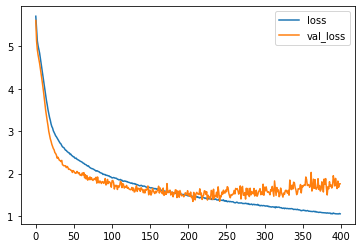

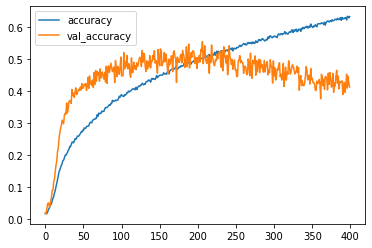

In [ ]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()



# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

#### Split the data before normalizing. The training the model using 3 dense and no dropout

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15,
                                                    shuffle=True,
                                                    stratify=Y,  # To ensure all sets in training and represented in testing
                                                    random_state=42)


lengthY_train = len(set(y_train))
lengthY_test = len(set(y_test))

if (lengthY_train != lengthY_test): # Test whether training and testing set are equal
    print("Training will generate an error because the test set does not have all samples of the train set. This is due to imbalanced classification. See  error in image below")
else:
    print("All targets are captured in both the training, testing and validating set. \nThe splitting was properly stratified")

print("The shape of training set", X_train.shape)
print("The shape of testing set", X_test.shape)


# normalize the training and testing data features using min max normalization
X_trainN = (X_train-np.min(X_train))/(np.max(X_train)-np.min(X_train))
X_testN = (X_test-np.min(X_test))/(np.max(X_test)-np.min(X_test))
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)


# Reshape the Training and testing features data to 2x3 vector
X_trainN = X_trainN.reshape(-1, 2, 3)
X_testN = X_testN.reshape(-1, 2, 3)
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)


# Add an extra dimension to both data to meet the CNN model requirement
X_trainN = np.expand_dims(X_trainN, -1)
X_testN = np.expand_dims(X_testN, -1)
print("The shape of training set", X_trainN.shape)
print("The shape of testing set", X_testN.shape)



# number of classes in train
K = len(set(y_train))
print("number of classes: ", K)


# One hot encode the targets

y_train = to_categorical(y_train, K)
y_test = to_categorical(y_test, K)



# Build the model using the fucntional API
i = Input(shape=X_trainN[0].shape) # same as (2, 3, 1)
x = Conv2D(16, (1,1), strides=1, activation='relu')(i)
x = Conv2D(32, (1,1), strides=1, activation='relu')(x)
x = Flatten()(x) # convert matrix into feature vector
x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile and fit
# Note: make sure you are using the GPU for this:
opt = tf.keras.optimizers.Adam(0.0001)
model.compile(optimizer= opt, # Default learning rate was very poor as accuracy was bellow 1%
              loss='categorical_crossentropy', # sparse_categorical_crossentropy scored below 1%
              metrics=['accuracy'])
r = model.fit(X_trainN, y_train, validation_data=(X_testN, y_test), epochs=400)




All targets are captured in both the training, testing and validating set. 
The splitting was properly stratified
The shape of training set (18722, 6)
The shape of testing set (3305, 6)
The shape of training set (18722, 6)
The shape of testing set (3305, 6)
The shape of training set (18722, 2, 3)
The shape of testing set (3305, 2, 3)
The shape of training set (18722, 2, 3, 1)
The shape of testing set (3305, 2, 3, 1)
number of classes:  317
Epoch 1/400
586/586 [==============================] - 3s 5ms/step - loss: 5.6952 - accuracy: 0.0184 - val_loss: 5.5697 - val_accuracy: 0.0197
Epoch 2/400
586/586 [==============================] - 3s 5ms/step - loss: 5.3154 - accuracy: 0.0189 - val_loss: 4.9904 - val_accuracy: 0.0203
Epoch 3/400
586/586 [==============================] - 3s 5ms/step - loss: 4.9585 - accuracy: 0.0267 - val_loss: 4.7408 - val_accuracy: 0.0369
Epoch 4/400
586/586 [==============================] - 3s 5ms/step - loss: 4.7840 - accuracy: 0.0374 - val_loss: 4.5983 - val_a

Poor result because the data collection approach had limitations. Observe that dropout was making the validation even better, but the fact that many of the dataset was unusable made it stop generalizing well. You obviously cannot train a system using onlly 2 captures of a location since one will be used for training and the other for validation

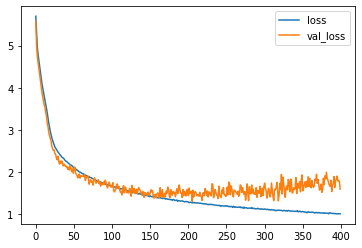

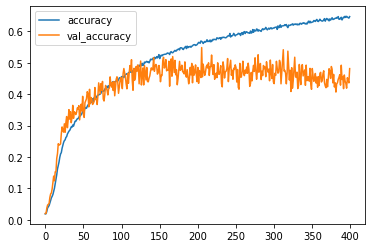

In [ ]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()



# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

#Single watch with a minimum of 17 usesful points at any location ID giving exceptional results of roughly 94%, with just a quarter of the number of epochs

In [ ]:
# For my geomagnetic
geodata_pd = pd.read_csv("geoMagXandIDSingleWatch.csv")
geodata_pd.head()

# remove space in column names
new_coumn_names = {' AccelerationX':'AccelerationX', ' AccelerationY':"AccelerationY", ' AccelerationZ':"AccelerationZ",
                   ' MagneticFieldX':"MagneticFieldX", ' MagneticFieldY':"MagneticFieldY", ' MagneticFieldZ':"MagneticFieldZ",
                   ' Z-AxisAgle(Azimuth)':"Azimuth_Z", ' X-AxisAngle(Pitch)':"Pitch_X", ' Y-AxisAngle(Roll)':"Roll_Y", ' GyroX':"GyroX", ' GyroY':"GyroY", ' GyroZ':"GyroZ"}
geodata_pd.rename(columns = new_coumn_names, inplace = True)
features = ["MagneticFieldX", "MagneticFieldY", "MagneticFieldZ", "Roll_Y", "Pitch_X", "Azimuth_Z"]

# From Pandas series To numpy array
ntmpY = np.array(geodataY)

# To pandas DF to numpy array
ntmpX = np.array(geodataX)

print("The minimum Place ID value before ordering", ntmpY.min())
print("The maximum Place ID value before ordering", ntmpY.max())
print("number of classes: ", len(set(ntmpY)))
print()

# Reorder the ID to enable it work in categorical cross entropy loss function
seriesID = pd.Series(ntmpY)
ntmpY = seriesID.astype("category").cat.codes


print("The minimum Place ID value before ordering", ntmpY.min())
print("The maximum Place ID value before ordering", ntmpY.max())
print("number of classes: ", len(set(tmpY)))

from sklearn.model_selection import train_test_split
# Split the data into training and testing. Using Stratify with the complete set

nX_train, nX_test, ny_train, ny_test = train_test_split(ntmpX, ntmpY, test_size=0.15,
                                                    shuffle=True,
                                                    stratify=ntmpY,
                                                    random_state=42)

print("number of classes in train: ", len(set(ny_train)))
print("number of classes in test: ", len(set(ny_test)))

# Now both training and testing set have the same target classes in them
print("The shape of training set", nX_train.shape)
print("The shape of testing set", nX_test.shape)

print("The shape of training target", ny_train.shape)
print("The shape of testing target", ny_test.shape)

# Reshape the Training features data to 2x3 vector meet the CNN model requirement
nX_train = nX_train.reshape(-1, 2, 3)
print(nX_train.shape)
print(type(nX_train))

# Reshape the Testing features data to 2x3 vector
nX_test = nX_test.reshape(-1, 2, 3)
print(nX_test.shape)
print(type(nX_test))


# Add an extra dimension to both data to meet the CNN model requirement
nX_train = np.expand_dims(nX_train, -1)
nX_test = np.expand_dims(nX_test, -1)
print("The shape of training set", nX_train.shape)
print("The shape of testing set", nX_test.shape)


# number of classes in test
K = len(set(ny_test))
print("number of classes: ", K)

# Shows it was not fully stratified, or it tried its best


# number of classes in train
K = len(set(ny_train))
print("number of classes: ", K)


# One hot encode the targets
from tensorflow.keras.utils import to_categorical

ny_train = to_categorical(ny_train, 317)
ny_test = to_categorical(ny_test, 317)


# Build the model using the fucntional API
i = Input(shape=nX_train[0].shape) # same as (2, 3, 1)
x = Conv2D(16, (1,1), strides=1, activation='relu')(i)
x = Conv2D(32, (1,1), strides=1, activation='relu')(x)
x = Flatten()(x) # convert matrix into feature vector
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile and fit
# Note: make sure you are using the GPU for this:
opt = tf.keras.optimizers.Adam(0.0001)
model.compile(optimizer= opt, # Default learning rate was very poor as accuracy was bellow 1%
              loss='categorical_crossentropy', # sparse_categorical_crossentropy scored below 1%
              metrics=['accuracy'])
nr = model.fit(nX_train, ny_train, validation_data=(nX_test, ny_test), epochs=80) # validation_data=(X_testN, y_test),

NameError: ignored

In [ ]:
# For my geomagnetic
watchData_pd = pd.read_csv("geoMagWatch_ID_X_Y.csv")
watchData_pd.head()

# remove space in column names
new_coumn_names = {' AccelerationX':'AccelerationX', ' AccelerationY':"AccelerationY", ' AccelerationZ':"AccelerationZ",
                   ' MagneticFieldX':"MagneticFieldX", ' MagneticFieldY':"MagneticFieldY", ' MagneticFieldZ':"MagneticFieldZ",
                   ' Z-AxisAgle(Azimuth)':"Azimuth_Z", ' X-AxisAngle(Pitch)':"Pitch_X", ' Y-AxisAngle(Roll)':"Roll_Y", ' GyroX':"GyroX", ' GyroY':"GyroY", ' GyroZ':"GyroZ"}
watchData_pd.rename(columns = new_coumn_names, inplace = True)
features = ["MagneticFieldX", "MagneticFieldY", "MagneticFieldZ", "Roll_Y", "Pitch_X", "Azimuth_Z"]

geodataX =  watchData_pd[features]
geodataY = watchData_pd["id"]

# From Pandas series To numpy array
ntmpY = np.array(geodataY)

# To pandas DF to numpy array
ntmpX = np.array(geodataX)

print("The minimum Place ID value before ordering", ntmpY.min())
print("The maximum Place ID value before ordering", ntmpY.max())
print("number of classes: ", len(set(ntmpY)))
print()

# Reorder the ID to enable it work in categorical cross entropy loss function
seriesID = pd.Series(ntmpY)
ntmpY = seriesID.astype("category").cat.codes


print("The minimum Place ID value before ordering", ntmpY.min())
print("The maximum Place ID value before ordering", ntmpY.max())
print("number of classes: ", len(set(ntmpY)))

from sklearn.model_selection import train_test_split
# Split the data into training and testing. Using Stratify with the complete set

nX_train, nX_test, ny_train, ny_test = train_test_split(ntmpX, ntmpY, test_size=0.15,
                                                    shuffle=True,
                                                    stratify=ntmpY,
                                                    random_state=42)

print("number of classes in train: ", len(set(ny_train)))
print("number of classes in test: ", len(set(ny_test)))

# Now both training and testing set have the same target classes in them
print("The shape of training set", nX_train.shape)
print("The shape of testing set", nX_test.shape)

print("The shape of training target", ny_train.shape)
print("The shape of testing target", ny_test.shape)

# Reshape the Training features data to 2x3 vector meet the CNN model requirement
nX_train = nX_train.reshape(-1, 2, 3)
print(nX_train.shape)
print(type(nX_train))

# Reshape the Testing features data to 2x3 vector
nX_test = nX_test.reshape(-1, 2, 3)
print(nX_test.shape)
print(type(nX_test))


# Add an extra dimension to both data to meet the CNN model requirement
nX_train = np.expand_dims(nX_train, -1)
nX_test = np.expand_dims(nX_test, -1)
print("The shape of training set", nX_train.shape)
print("The shape of testing set", nX_test.shape)


# number of classes in test
K = len(set(ny_test))
print("number of classes: ", K)

# Shows it was not fully stratified, or it tried its best


# number of classes in train
K = len(set(ny_train))
print("number of classes: ", K)


# One hot encode the targets
from tensorflow.keras.utils import to_categorical

ny_train = to_categorical(ny_train, 317)
ny_test = to_categorical(ny_test, 317)


# Build the model using the keras fucntional API
i = Input(shape=nX_train[0].shape) # same as (2, 3, 1)
x = Conv2D(16, (2,1), strides=1, activation='relu')(i)
x = Conv2D(32, (1,1), strides=1, activation='relu')(x)
x = Flatten()(x) # convert matrix into feature vector; # x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x); # x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x); # x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x); # x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)
model = Model(i, x)

# Compile and fit
# Note: make sure you are using the GPU for this:
opt = tf.keras.optimizers.Adam(0.0001)
model.compile(optimizer= opt, # Default learning rate was very poor as accuracy was bellow 1%
              loss='categorical_crossentropy', # sparse_categorical_crossentropy scored below 1%
              metrics=['accuracy'])
nr = model.fit(nX_train, ny_train, validation_data=(nX_test, ny_test), epochs=80) # validation_data=(X_testN, y_test),

The minimum Place ID value before ordering 0
The maximum Place ID value before ordering 324
number of classes:  317

The minimum Place ID value before ordering 0
The maximum Place ID value before ordering 316
number of classes:  317
number of classes in train:  317
number of classes in test:  317
The shape of training set (9798, 6)
The shape of testing set (1730, 6)
The shape of training target (9798,)
The shape of testing target (1730,)
(9798, 2, 3)
<class 'numpy.ndarray'>
(1730, 2, 3)
<class 'numpy.ndarray'>
The shape of training set (9798, 2, 3, 1)
The shape of testing set (1730, 2, 3, 1)
number of classes:  317
number of classes:  317
Epoch 1/80
307/307 [==============================] - 2s 5ms/step - loss: 5.4670 - accuracy: 0.0914 - val_loss: 4.1874 - val_accuracy: 0.1514
Epoch 2/80
307/307 [==============================] - 1s 4ms/step - loss: 3.7106 - accuracy: 0.1783 - val_loss: 3.2697 - val_accuracy: 0.2058
Epoch 3/80
307/307 [==============================] - 2s 5ms/step - l

In [ ]:
print(model.summary())


Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 2, 3, 1)]         0         
                                                                 
 conv2d_6 (Conv2D)           (None, 2, 1, 16)          64        
                                                                 
 conv2d_7 (Conv2D)           (None, 2, 1, 32)          544       
                                                                 
 flatten_3 (Flatten)         (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 317)               20605     
                                                                 
 dense_13 (Dense)            (None, 317)               100806    
                                                                 
 dense_14 (Dense)            (None, 317)               1008

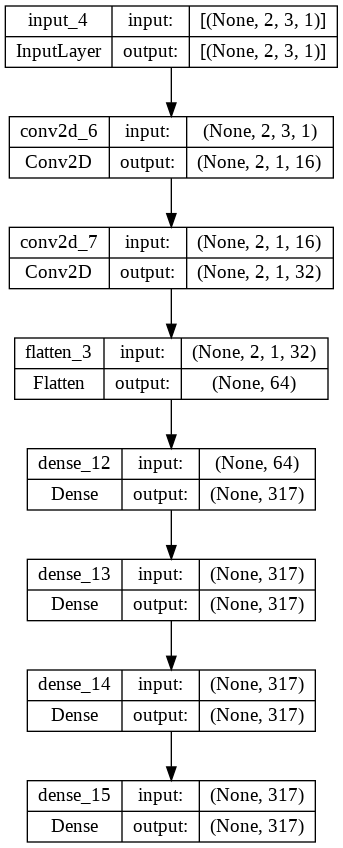

In [ ]:
model_img ='model4_.png'
tf.keras.utils.plot_model(model, to_file=model_img, show_shapes=True)

This is what happens when you have good data. The watch had

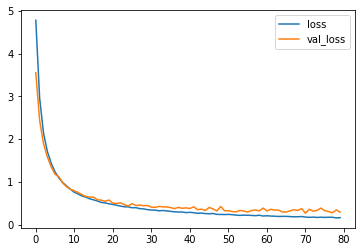

In [ ]:
# Plot loss per iteration
plt.plot(nr.history['loss'], label='loss')
plt.plot(nr.history['val_loss'], label='val_loss')
plt.legend()

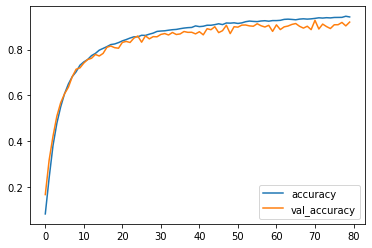

In [ ]:
# Plot accuracy per iteration
plt.plot(nr.history['accuracy'], label='accuracy')
plt.plot(nr.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [ ]:
p_test = model.predict(nX_test).argmax(axis=1)

55/55 [==============================] - 0s 2ms/step


In [ ]:
ny_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
p_test

array([ 96, 103,  55, ..., 105,  65, 291])

In [ ]:
# rounded_predictions = model.predict_classes(test_images, batch_size=128, verbose=0)
rounded_labels=np.argmax(ny_test, axis=1)
rounded_predictions = np.argmax(p_test, axis=1) # Already in rounded labels

AxisError: ignored

In [ ]:
rounded_labels

array([ 96, 103,  55, ..., 105,  65, 291])

In [ ]:
model.fit(train_images, train_labels, epochs=10, batch_size=128)

rounded_predictions = model.predict_classes(test_images, batch_size=128, verbose=0)

cm = confusion_matrix(test_labels, rounded_predictions)

p_test = model.predict(nX_test).argmax(axis=1)
cm = confusion_matrix(ny_test, p_test)



rounded_labels=np.argmax(test_labels, axis=1)
rounded_labels[1]


from sklearn.metrics import confusion_matrix
cm = confusion_matrix(rounded_labels, rounded_predictions)
cm

In [ ]:
# Show some misclassified examples
misclassified_idx = np.where(p_test != rounded_labels)[0]
i = np.random.choice(misclassified_idx)
print(p_test[i], "mistook for ", rounded_labels[i])


231 mistook for  229


In [ ]:
actual = []; wrong_prediction = [];
for i in misclassified_idx:
  actual.append(rounded_labels[i]) ; wrong_prediction.append(p_test[i]);

df_actual_pred = pd.DataFrame(list(zip(actual, wrong_prediction)), columns =['Actual', 'wrong'])


In [ ]:
df_actual_pred

,Actual,wrong
0,303,297
1,47,46
2,33,32
3,38,97
4,69,127
...,...,...
145,140,139
146,140,139
147,286,292
148,229,231


In [ ]:
p_test.shape

(1730,)

## Map of the location in Firat University

In [ ]:
df_pMapFaculty = pd.read_excel("bilgMu_cat3_PointMap.xlsx", header=0)
df_pMapFaculty

,id,y,x,Unnamed: 3
0,1,0.66,0.66,NaN
1,2,0.66,1.32,NaN
2,3,0.66,1.98,NaN
3,4,0.66,2.64,NaN
4,5,0.66,17.82,NaN
...,...,...,...,...
413,414,17.16,11.88,NaN
414,415,17.16,12.54,NaN
415,416,17.16,13.20,change point
416,417,17.82,0.66,NaN


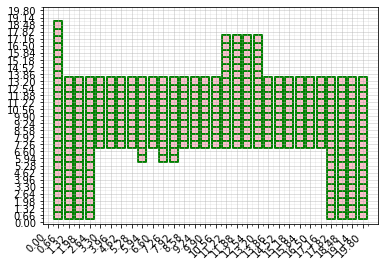

In [ ]:
x = df_pMapFaculty["x"]
y = df_pMapFaculty["y"]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

plt.scatter(x, y, c ="pink",
            linewidths = 2,
            marker ="s",
            edgecolor ="green",
            s = 50)

# Major ticks every 20, minor ticks every 5
major_ticks = np.arange(0, 20.46, 0.66) # .66 is 2 tiles
minor_ticks = np.arange(0, 20.46, 0.33) # .33 is a single tile

ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

#### Plot Model

In [ ]:
!pip install pydo

     ------------------------------------ 833.9/833.9 kB 148.5 kB/s eta 0:00:00
     -------------------------------------- 85.4/85.4 kB 228.4 kB/s eta 0:00:00
     -------------------------------------- 41.7/41.7 kB 403.6 kB/s eta 0:00:00
     ------------------------------------ 135.5/135.5 kB 400.1 kB/s eta 0:00:00
     ------------------------------------ 172.6/172.6 kB 452.3 kB/s eta 0:00:00
     -------------------------------------- 90.0/90.0 kB 463.7 kB/s eta 0:00:00


In [ ]:


from tensorflow.keras.utils import plot_model

# Build the model using the fucntional API
i = Input((2, 3, 1)) # same as (2, 3, 1)
x = Conv2D(16, (1,1), strides=1, activation='relu')(i)
x = Conv2D(32, (1,1), strides=1, activation='relu')(x)
x = Flatten()(x) # convert matrix into feature vector
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='relu')(x)
# x = Dropout(0.2)(x)
x = Dense(317, activation='softmax')(x)

model = Model(i, x)

model_img ='model_.png'
plot_model(model, to_file=model_img, show_shapes=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


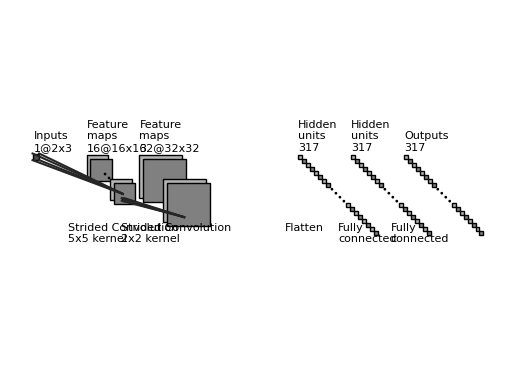

In [ ]:
"""
Copyright (c) 2017, Gavin Weiguang Ding
All rights reserved.
Redistribution and use in source and binary forms, with or without
    modification, are permitted provided that the following conditions are met:
1. Redistributions of source code must retain the above copyright notice, this
    list of conditions and the following disclaimer.
2. Redistributions in binary form must reproduce the above copyright notice,
    this list of conditions and the following disclaimer in the documentation
    and/or other materials provided with the distribution.
3. Neither the name of the copyright holder nor the names of its contributors
    may be used to endorse or promote products derived from this software
    without specific prior written permission.
THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
    AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
    IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
    ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE
    LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR
    CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF
    SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS
    INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN
    CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE)
    ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE
    POSSIBILITY OF SUCH DAMAGE.
"""


import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcdefaults()
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

NumDots = 4
NumConvMax = 8
NumFcMax = 20
White = 1.
Light = 0.7
Medium = 0.5
Dark = 0.3
Darker = 0.15
Black = 0.


def add_layer(patches, colors, size=(24, 24), num=5,
              top_left=[0, 0],
              loc_diff=[3, -3],
              ):
    # add a rectangle
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    for ind in range(num):
        patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
        if ind % 2:
            colors.append(Medium)
        else:
            colors.append(Light)


def add_layer_with_omission(patches, colors, size=(24, 24),
                            num=5, num_max=8,
                            num_dots=4,
                            top_left=[0, 0],
                            loc_diff=[3, -3],
                            ):
    # add a rectangle
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    this_num = min(num, num_max)
    start_omit = (this_num - num_dots) // 2
    end_omit = this_num - start_omit
    start_omit -= 1
    for ind in range(this_num):
        if (num > num_max) and (start_omit < ind < end_omit):
            omit = True
        else:
            omit = False

        if omit:
            patches.append(
                Circle(loc_start + ind * loc_diff + np.array(size) / 2, 0.5))
        else:
            patches.append(Rectangle(loc_start + ind * loc_diff,
                                     size[1], size[0]))

        if omit:
            colors.append(Black)
        elif ind % 2:
            colors.append(Medium)
        else:
            colors.append(Light)


def add_mapping(patches, colors, start_ratio, end_ratio, patch_size, ind_bgn,
                top_left_list, loc_diff_list, num_show_list, size_list):

    start_loc = top_left_list[ind_bgn] \
        + (num_show_list[ind_bgn] - 1) * np.array(loc_diff_list[ind_bgn]) \
        + np.array([start_ratio[0] * (size_list[ind_bgn][1] - patch_size[1]),
                    - start_ratio[1] * (size_list[ind_bgn][0] - patch_size[0])]
                   )




    end_loc = top_left_list[ind_bgn + 1] \
        + (num_show_list[ind_bgn + 1] - 1) * np.array(
            loc_diff_list[ind_bgn + 1]) \
        + np.array([end_ratio[0] * size_list[ind_bgn + 1][1],
                    - end_ratio[1] * size_list[ind_bgn + 1][0]])


    patches.append(Rectangle(start_loc, patch_size[1], -patch_size[0]))
    colors.append(Dark)
    patches.append(Line2D([start_loc[0], end_loc[0]],
                          [start_loc[1], end_loc[1]]))
    colors.append(Darker)
    patches.append(Line2D([start_loc[0] + patch_size[1], end_loc[0]],
                          [start_loc[1], end_loc[1]]))
    colors.append(Darker)
    patches.append(Line2D([start_loc[0], end_loc[0]],
                          [start_loc[1] - patch_size[0], end_loc[1]]))
    colors.append(Darker)
    patches.append(Line2D([start_loc[0] + patch_size[1], end_loc[0]],
                          [start_loc[1] - patch_size[0], end_loc[1]]))
    colors.append(Darker)



def label(xy, text, xy_off=[0, 4]):
    plt.text(xy[0] + xy_off[0], xy[1] + xy_off[1], text,
             family='sans-serif', size=8)


if __name__ == '__main__':

    fc_unit_size = 3
    layer_width = 40 # Affects the spacing
    flag_omit = True

    patches = []
    colors = []

    fig, ax = plt.subplots()



    ############################
    # conv layers
    size_list = [(2, 3), (16, 16), (32, 32)]
    num_list = [1, 16, 32]
    x_diff_list = [0, layer_width, layer_width, layer_width, layer_width]
    text_list = ['Inputs'] + ['Feature\nmaps'] * (len(size_list) - 1)
    loc_diff_list = [[3, -3]] * len(size_list)

    num_show_list = list(map(min, num_list, [NumConvMax] * len(num_list)))
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]

    for ind in range(len(size_list)-1,-1,-1):
        if flag_omit:
            add_layer_with_omission(patches, colors, size=size_list[ind],
                                    num=num_list[ind],
                                    num_max=NumConvMax,
                                    num_dots=NumDots,
                                    top_left=top_left_list[ind],
                                    loc_diff=loc_diff_list[ind])
        else:
            add_layer(patches, colors, size=size_list[ind],
                      num=num_show_list[ind],
                      top_left=top_left_list[ind], loc_diff=loc_diff_list[ind])
        label(top_left_list[ind], text_list[ind] + '\n{}@{}x{}'.format(
            num_list[ind], size_list[ind][0], size_list[ind][1]))

    ############################
    # in between layers
    start_ratio_list = [[0.4, 0.5], [0.4, 0.8]] # , [0.4, 0.5], [0.4, 0.8]
    end_ratio_list = [[0.4, 0.5], [0.4, 0.8]] # , [0.4, 0.5], [0.4, 0.8]


    patch_size_list = [(1, 1), (1, 1)] # The labels for the filter sizes
    ind_bgn_list = range(len(patch_size_list))
    text_list = ['Strided Convolution', 'Strided Convolution']

    for ind in range(len(patch_size_list)):
        add_mapping(
            patches, colors, start_ratio_list[ind], end_ratio_list[ind],
            patch_size_list[ind], ind,
            top_left_list, loc_diff_list, num_show_list, size_list)
        label(top_left_list[ind], text_list[ind] + '\n{}x{} kernel'.format(
            patch_size_list[ind][0], patch_size_list[ind][1]), xy_off=[26, -65]
        )


    ############################
    # fully connected layers
    size_list = [(fc_unit_size, fc_unit_size)] * 3
    num_list = [317, 317, 317, 317]
    num_show_list = list(map(min, num_list, [NumFcMax] * len(num_list)))
    x_diff_list = [sum(x_diff_list) + layer_width, layer_width, layer_width]
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]
    loc_diff_list = [[fc_unit_size, -fc_unit_size]] * len(top_left_list)
    text_list = ['Hidden\nunits'] * (len(size_list) - 1) + ['Outputs']

    for ind in range(len(size_list)):
        if flag_omit:
            add_layer_with_omission(patches, colors, size=size_list[ind],
                                    num=num_list[ind],
                                    num_max=NumFcMax,
                                    num_dots=NumDots,
                                    top_left=top_left_list[ind],
                                    loc_diff=loc_diff_list[ind])
        else:
            add_layer(patches, colors, size=size_list[ind],
                      num=num_show_list[ind],
                      top_left=top_left_list[ind],
                      loc_diff=loc_diff_list[ind])
        label(top_left_list[ind], text_list[ind] + '\n{}'.format(
            num_list[ind]))


# The list of labels for the dense layers
    text_list = ['Flatten\n', 'Fully\nconnected', 'Fully\nconnected', 'Fully\nconnected']

    for ind in range(len(size_list)):
        label(top_left_list[ind], text_list[ind], xy_off=[-10, -65])

    ############################
    for patch, color in zip(patches, colors):
        patch.set_color(color * np.ones(3))
        if isinstance(patch, Line2D):
            ax.add_line(patch)
        else:
            patch.set_edgecolor(Black * np.ones(3))
            ax.add_patch(patch)

#     plt.tight_layout()
    plt.axis('equal')
    plt.axis('off')
    plt.show()
    fig.set_size_inches(8, 2.5)

    fig_dir = './'
    fig_ext = '.png'
    fig.savefig(os.path.join(fig_dir, 'convnet_fig' + fig_ext),
                bbox_inches='tight', pad_inches=0)

Path and error in distance calculation

In [ ]:
# Path
pathWatch = []

for ID in listIDPhone1:
    if ID not in pathPhone1:
        pathPhone1.append(ID)


# path

In [ ]:
path_x_cordsPhone1 = []
path_y_cordsPhone1 = []
# Phone1PathFrequency = [] # Was used to crosscheck what was happening

for id in pathPhone1:
    if id == 0: # Dataset author skipped  in their mapping that cordinate 0,0 was transvered
            path_x_cordsPhone1.append(0.0)
            path_y_cordsPhone1.append(0.0)
#             Phone1PathFrequency.append(id)
    for i in range(df_pMap.shape[0]):
        if df_pMap["ID"][i] == id:
            path_x_cordsPhone1.append(df_pMap["X"][i])
            path_y_cordsPhone1.append(df_pMap["Y"][i])
#             Phone1PathFrequency.append(id)

